<a href="https://colab.research.google.com/github/KaiAzrael/Portfolio-Optimisation-using-Black-Litterman/blob/main/Portfolio_Optimisation_using_Black_Litterman.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [95]:
import pandas as pd
import numpy as np
from numpy import *
from numpy.linalg import inv, multi_dot
import matplotlib.pyplot as plt
from seaborn import heatmap
import yfinance as yf
import cvxpy as cp
from sklearn.linear_model import LinearRegression

In [96]:
asset_name_to_id_map = {
    'Nippon India ETF Liquid Bees': 'LIQUIDBEES.NS',
    'DLF Ltd.': 'DLF.NS',
    'Larsen & Toubro Ltd.': 'LT.NS',
    'Nifty IT Index': '^CNXIT',
    'Hindustan Zinc Ltd.': 'HINDZINC.NS',
    'HDFC Gold ETF': 'GOLDBEES.NS',
    'Bharat Electronics Ltd.': 'BEL.NS',
    'Nifty Mid Cap 50 Index': '^NSEMDCP50',
    'Invesco DB Commodity Index Tracing Fund': 'DBC',
    'WisdomTree India Earnings ETF': 'EPI',
    'Fidelity Select Technology Portfolio': 'FSPTX',
    'Fidelity Blue Chip Growth Fund': 'FBGRX',
    'Vanguard Mid-Cap Growth Index Fund Admiral Shares': 'VMGRX',
    'Vanguard Small-Cap Index Fund Admiral Shares': 'VSMAX',
    'Vanguard Short-Term Investment-Grade Fund Admiral Shares': 'VSIGX',
    'Vanguard Total Stock Market Index Fund Admiral Shares': 'VTSAX',
    'VIX Index': '^VIX',
    'Vanguard Real Estate Index Fund Admiral Shares': 'VGSLX',
    'S&P 500 Benchmark': 'SPY',
    'Niftybees Benchmark': 'NIFTYBEES.NS'
}

print("Asset name ID map created.")

Asset name ID map created.


In [97]:
asset_symbols = list(asset_name_to_id_map.values())
numofasset = len(asset_symbols)
numofportfolio = 5000

In [98]:
import yfinance as yf
import pandas as pd

_MONETARY_INFO_KEYS = [
    'marketCap', 'totalAssets', 'totalRevenue', 'ebitda', 'regularMarketOpen',
    'regularMarketDayHigh', 'regularMarketDayLow', 'regularMarketPreviousClose',
    'regularMarketPrice', 'fiftyTwoWeekHigh', 'fiftyTwoWeekLow', 'bookValue'
]

_MONETARY_DF_COLS = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Dividends']


class InrTicker:
    """A wrapper for yf.Ticker that safely converts USD data to INR using daily exchange rates."""

    def __init__(self, symbol):
        self.symbol = symbol
        self._ticker = yf.Ticker(self.symbol)
        self._original_info = self._ticker.info
        self.info = self._convert_info()
        self._exchange_rates = None  # Cache for exchange rates

    def _convert_info(self):
        info_copy = self._original_info.copy()
        if info_copy.get('currency', '').upper() == 'USD':
            # Get current exchange rate for info conversion
            try:
                inr_ticker = yf.Ticker('INR=X')
                current_rate = inr_ticker.history(period='1d')['Close'].iloc[-1]
            except:
                print(f"Warning: Could not fetch current exchange rate for {self.symbol} info. Using approximate rate.")
                current_rate = 83.0  # Fallback rate

            for key in _MONETARY_INFO_KEYS:
                if key in info_copy and isinstance(info_copy.get(key), (int, float)):
                    info_copy[key] *= current_rate
            info_copy['currency'] = 'INR'
        return info_copy

    def _get_exchange_rates(self, start_date, end_date):
        """Fetch historical USD/INR exchange rates for the given date range."""
        try:
            inr_ticker = yf.Ticker('INR=X')
            # Fetch with a bit of buffer to ensure coverage
            exchange_data = inr_ticker.history(start=start_date, end=end_date)
            if exchange_data.empty:
                print("Warning: No exchange rate data found. Using approximate rate of 83.0")
                return None
            # Remove timezone info to match asset data
            exchange_rates = exchange_data['Close']
            exchange_rates.index = exchange_rates.index.tz_localize(None)
            return exchange_rates
        except Exception as e:
            print(f"Error fetching exchange rates: {e}. Using approximate rate of 83.0")
            return None

    def history(self, *args, **kwargs):
        df = self._ticker.history(*args, **kwargs)

        if self._original_info.get('currency', '').upper() == 'USD' and not df.empty:
            # Get exchange rates for the data's date range
            start_date = df.index.min()
            end_date = df.index.max()

            exchange_rates = self._get_exchange_rates(start_date, end_date)

            if exchange_rates is not None:
                # Align exchange rates with data (forward-fill for weekends/holidays)
                exchange_rates = exchange_rates.reindex(df.index, method='ffill')

                # Convert monetary columns using daily rates
                for col in _MONETARY_DF_COLS:
                    if col in df.columns:
                        df[col] = df[col] * exchange_rates
            else:
                # Fallback to fixed rate if exchange rate fetch failed
                fallback_rate = 83.0
                for col in _MONETARY_DF_COLS:
                    if col in df.columns:
                        df[col] *= fallback_rate

        return df


def yf_inr_download(tickers, *args, **kwargs):
    """
    A wrapper for yf.download that safely converts USD data to INR using daily exchange rates.
    """
    # 1. Download original data first
    data = yf.download(tickers, *args, **kwargs)
    if data.empty:
        return data

    # 2. Find which tickers are in USD
    tickers_list = tickers.replace(',', ' ').split()
    usd_tickers = []
    for ticker_symbol in tickers_list:
        try:
            info = yf.Ticker(ticker_symbol).info
            if info.get('currency', '').upper() == 'USD':
                usd_tickers.append(ticker_symbol)
        except Exception:
            pass  # Ignore tickers that can't be found

    if not usd_tickers:
        return data  # Return original data if no USD tickers to convert

    # 3. Get exchange rates for the date range
    start_date = data.index.min()
    end_date = data.index.max()

    try:
        inr_ticker = yf.Ticker('INR=X')
        exchange_data = inr_ticker.history(start=start_date, end=end_date)
        # Remove timezone info to match asset data
        exchange_rates = exchange_data['Close']
        exchange_rates.index = exchange_rates.index.tz_localize(None)
        exchange_rates = exchange_rates.reindex(data.index, method='ffill')
    except Exception as e:
        print(f"Error fetching exchange rates: {e}. Using fixed rate of 83.0")
        exchange_rates = 83.0  # Fallback to fixed rate

    # 4. Convert only the USD tickers
    print(f"Converting data to INR for: {', '.join(usd_tickers)}")
    for ticker_symbol in usd_tickers:
        for col in _MONETARY_DF_COLS:
            # Handle both single and multi-ticker dataframes
            if isinstance(data.columns, pd.MultiIndex) and (col, ticker_symbol) in data.columns:
                data[(col, ticker_symbol)] *= exchange_rates
            elif not isinstance(data.columns, pd.MultiIndex) and col in data.columns and len(tickers_list) == 1:
                data[col] *= exchange_rates

    return data

In [99]:
assets_string = ' '.join(asset_symbols)
data = yf_inr_download(assets_string, start="2015-08-01", end="2025-07-31", auto_adjust=False)["Adj Close"]

# Create a reverse mapping from ticker symbol to asset name
asset_id_to_name_map = {v: k for k, v in asset_name_to_id_map.items()}

# 2. Drop any columns from data that consist entirely of NaN values.
data = data.dropna(axis=1, how='all')

# 3. Apply forward-fill (ffill()) to handle any remaining NaN values.
data = data.ffill()

# 4. Apply backward-fill (bfill()) to handle any remaining NaN values.
data = data.bfill()

# 5. Drop any rows from data that still contain NaN values after filling.
data = data.dropna(axis=0, how='any')

# Rename columns from ticker symbols to full asset names
data = data.rename(columns=asset_id_to_name_map)

print("Data downloaded, cleaned, and columns renamed. Displaying the first 5 rows:")
print(data.head())

[*********************100%***********************]  20 of 20 completed


Converting data to INR for: DBC, EPI, FSPTX, FBGRX, VMGRX, VSMAX, VSIGX, VTSAX, ^VIX, VGSLX, SPY
Data downloaded, cleaned, and columns renamed. Displaying the first 5 rows:
Ticker      Bharat Electronics Ltd.  Invesco DB Commodity Index Tracing Fund  \
Date                                                                           
2015-08-03                34.516472                               864.952268   
2015-08-04                34.536980                               871.942416   
2015-08-05                33.844406                               864.448813   
2015-08-06                33.317139                               862.226054   
2015-08-07                33.185738                               859.385290   

Ticker        DLF Ltd.  WisdomTree India Earnings ETF  \
Date                                                    
2015-08-03  103.555962                    1221.404438   
2015-08-04  103.152496                    1233.064751   
2015-08-05  109.473442                

In [100]:
data2=yf_inr_download('NIFTYBEES.NS LIQUIDBEES.NS', start="2015-08-01", end="2025-07-31", auto_adjust=False)["Adj Close"]
rows_to_drop = data2.index.difference(data.index)
data2 = data2.drop(rows_to_drop)
data2

[*********************100%***********************]  2 of 2 completed


Ticker,LIQUIDBEES.NS,NIFTYBEES.NS
Date,,
2015-08-03,678.680176,86.635002
2015-08-04,678.672913,86.302002
2015-08-05,678.680176,86.712997
2015-08-06,678.672913,87.000999
2015-08-07,678.680176,86.711998
...,...,...
2025-07-24,990.239380,282.100006
2025-07-25,990.239380,280.029999
2025-07-28,990.229431,278.489990


In [101]:
data.to_csv('data.csv')
data2.to_csv('data2.csv')

# Combine data and data2 to create data3 in one line of code, including cleaning
data3 = pd.concat([data, data2], axis=1, join='outer').dropna(axis=1, how='all').ffill().bfill().dropna(axis=0, how='any')

data3

Ticker,Bharat Electronics Ltd.,Invesco DB Commodity Index Tracing Fund,DLF Ltd.,WisdomTree India Earnings ETF,Fidelity Blue Chip Growth Fund,Fidelity Select Technology Portfolio,HDFC Gold ETF,Hindustan Zinc Ltd.,Nippon India ETF Liquid Bees,Larsen & Toubro Ltd.,...,Vanguard Real Estate Index Fund Admiral Shares,Vanguard Mid-Cap Growth Index Fund Admiral Shares,Vanguard Short-Term Investment-Grade Fund Admiral Shares,Vanguard Small-Cap Index Fund Admiral Shares,Vanguard Total Stock Market Index Fund Admiral Shares,Nifty IT Index,Nifty Mid Cap 50 Index,VIX Index,LIQUIDBEES.NS,NIFTYBEES.NS
Date,,,,,,,,,,,,,,,,,,,,,
2015-08-03,34.516472,864.952268,103.555962,1221.404438,1803.294070,139.149754,22.740999,62.681927,678.680176,1004.374268,...,4782.495203,333.475496,1091.056758,3161.334994,2845.818147,11466.400391,3480.467041,803.588821,678.680176,86.635002
2015-08-04,34.536980,871.942416,103.152496,1233.064751,1805.906378,138.845322,22.688000,61.403111,678.672913,1001.749634,...,4760.043658,333.459804,1089.022536,3162.966033,2846.280396,11415.549805,3527.064453,833.612007,678.672913,86.302002
2015-08-05,33.844406,864.448813,109.473442,1235.513608,1812.432316,139.495423,22.511999,61.422489,678.680176,1004.487488,...,4705.615631,333.653199,1081.359989,3156.108155,2842.959911,11618.000000,3536.664062,798.375708,678.680176,86.712997
2015-08-06,33.317139,862.226054,109.787247,1227.600402,1775.892877,137.953287,22.485500,60.298672,678.672913,1033.358643,...,4705.429194,328.443065,1081.753757,3117.337510,2813.865719,11616.500000,3544.463623,877.093937,678.672913,87.000999
2015-08-07,33.185738,859.385290,112.701164,1232.742014,1771.652920,137.836529,22.610500,60.240524,678.680176,1034.882568,...,4724.670197,328.380077,1083.869960,3105.520724,2806.908184,11597.049805,3539.713867,853.384915,678.680176,86.711998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-24,397.328247,1935.330778,822.930786,3979.524098,20286.343105,3005.278465,82.300003,446.100006,990.239380,3477.500000,...,11123.946921,2508.154230,1701.881692,10117.180490,13094.758994,36135.800781,16566.849609,1329.675975,990.239380,282.100006
2025-07-25,394.285309,1916.159710,820.299988,3961.100709,20375.963820,3016.192668,82.099998,439.200012,990.239380,3442.899902,...,11132.296481,2533.271984,1705.056418,10182.914338,13157.297061,35623.750000,16334.549805,1290.404373,990.239380,280.029999
2025-07-28,388.349091,1937.736686,787.200012,3917.861507,20486.080393,3041.507727,82.029999,432.049988,990.229431,3422.199951,...,10958.686938,2536.358929,1704.848774,10151.315558,13167.975022,35370.050781,16254.450195,1300.186713,990.229431,278.489990


In [102]:
data3.to_csv('data3.csv')
summary = data.describe().T
print(summary)
summary_bm = data2.describe().T
print(summary_bm)

                                                     count          mean  \
Ticker                                                                     
Bharat Electronics Ltd.                             2591.0     88.443162   
Invesco DB Commodity Index Tracing Fund             2591.0   1265.108668   
DLF Ltd.                                            2591.0    327.338796   
WisdomTree India Earnings ETF                       2591.0   2163.771805   
Fidelity Blue Chip Growth Fund                      2591.0   7243.473940   
Fidelity Select Technology Portfolio                2591.0    957.706338   
HDFC Gold ETF                                       2591.0     40.245248   
Hindustan Zinc Ltd.                                 2591.0    207.954315   
Nippon India ETF Liquid Bees                        2591.0    821.012095   
Larsen & Toubro Ltd.                                2591.0   1683.598135   
Niftybees Benchmark                                 2591.0    154.974705   
S&P 500 Benc

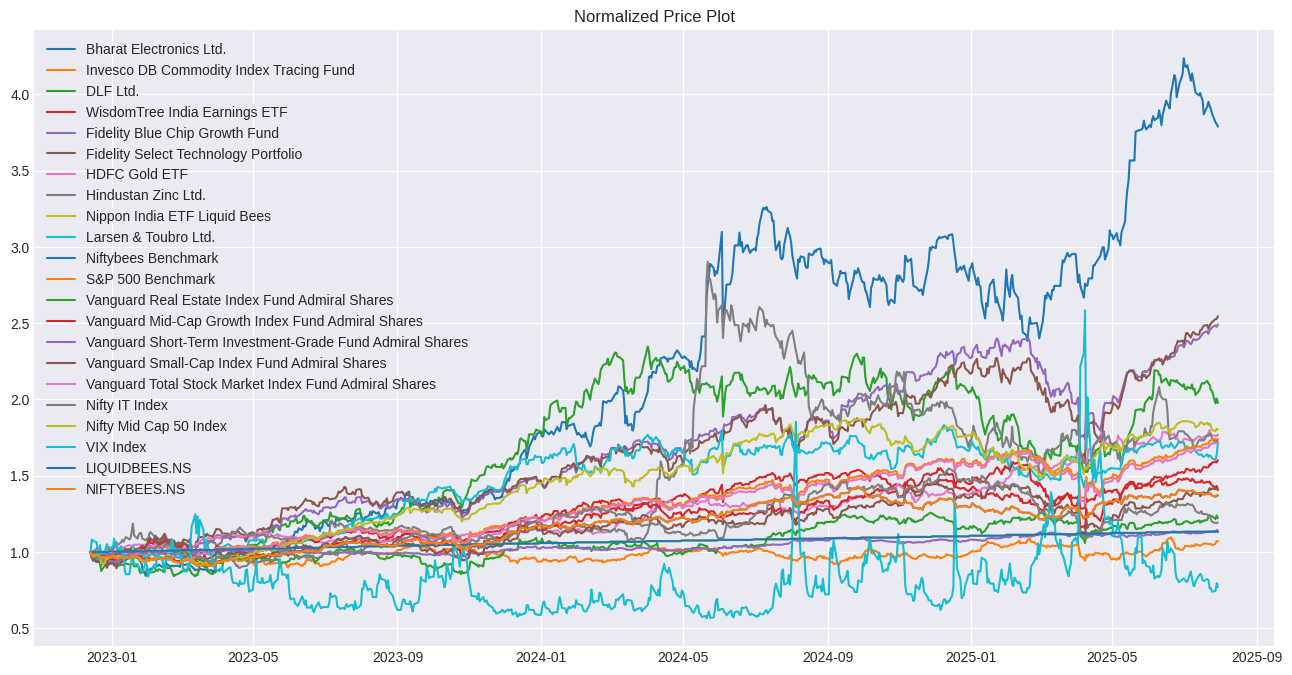

In [103]:
# Visualize the data
fig = plt.figure(figsize=(16,8))
ax = plt.axes()

ax.set_title('Normalized Price Plot')
ax.plot(data3[-682:]/data3.iloc[-682] * 1)
ax.legend(data3.columns, loc='upper left')
ax.grid(True)

In [104]:
returns = data.pct_change().fillna(0)
returns.head()

Ticker,Bharat Electronics Ltd.,Invesco DB Commodity Index Tracing Fund,DLF Ltd.,WisdomTree India Earnings ETF,Fidelity Blue Chip Growth Fund,Fidelity Select Technology Portfolio,HDFC Gold ETF,Hindustan Zinc Ltd.,Nippon India ETF Liquid Bees,Larsen & Toubro Ltd.,Niftybees Benchmark,S&P 500 Benchmark,Vanguard Real Estate Index Fund Admiral Shares,Vanguard Mid-Cap Growth Index Fund Admiral Shares,Vanguard Short-Term Investment-Grade Fund Admiral Shares,Vanguard Small-Cap Index Fund Admiral Shares,Vanguard Total Stock Market Index Fund Admiral Shares,Nifty IT Index,Nifty Mid Cap 50 Index,VIX Index
Date,,,,,,,,,,,,,,,,,,,,
2015-08-03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2015-08-04,0.000594,0.008082,-0.003896,0.009547,0.001449,-0.002188,-0.002331,-0.020402,-0.000011,-0.002613,-0.003844,0.000292,-0.004695,-0.000047,-0.001864,0.000516,0.000162,-0.004435,0.013388,0.037361
2015-08-05,-0.020053,-0.008594,0.061278,0.001986,0.003614,0.004682,-0.007757,0.000316,0.000011,0.002733,0.004762,-0.001477,-0.011434,0.000580,-0.007036,-0.002168,-0.001167,0.017735,0.002722,-0.042269
2015-08-06,-0.015579,-0.002571,0.002866,-0.006405,-0.020160,-0.011055,-0.001177,-0.018297,-0.000011,0.028742,0.003321,-0.010099,-0.000040,-0.015615,0.000364,-0.012284,-0.010234,-0.000129,0.002205,0.098598
2015-08-07,-0.003944,-0.003295,0.026541,0.004188,-0.002388,-0.000846,0.005559,-0.000964,0.000011,0.001475,-0.003322,-0.001340,0.004089,-0.000192,0.001956,-0.003791,-0.002473,-0.001674,-0.001340,-0.027031


In [105]:
returns_bm = data2.pct_change().fillna(0)
returns_bm.head()

Ticker,LIQUIDBEES.NS,NIFTYBEES.NS
Date,,
2015-08-03,0.000000,0.000000
2015-08-04,-0.000011,-0.003844
2015-08-05,0.000011,0.004762
2015-08-06,-0.000011,0.003321
2015-08-07,0.000011,-0.003322


In [106]:
log_returns = np.log(data) - np.log(data.shift(1))
log_returns.fillna(0)

Ticker,Bharat Electronics Ltd.,Invesco DB Commodity Index Tracing Fund,DLF Ltd.,WisdomTree India Earnings ETF,Fidelity Blue Chip Growth Fund,Fidelity Select Technology Portfolio,HDFC Gold ETF,Hindustan Zinc Ltd.,Nippon India ETF Liquid Bees,Larsen & Toubro Ltd.,Niftybees Benchmark,S&P 500 Benchmark,Vanguard Real Estate Index Fund Admiral Shares,Vanguard Mid-Cap Growth Index Fund Admiral Shares,Vanguard Short-Term Investment-Grade Fund Admiral Shares,Vanguard Small-Cap Index Fund Admiral Shares,Vanguard Total Stock Market Index Fund Admiral Shares,Nifty IT Index,Nifty Mid Cap 50 Index,VIX Index
Date,,,,,,,,,,,,,,,,,,,,
2015-08-03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2015-08-04,0.000594,0.008049,-0.003904,0.009501,0.001448,-0.002190,-0.002333,-0.020613,-0.000011,-0.002617,-0.003851,0.000292,-0.004706,-0.000047,-0.001866,0.000516,0.000162,-0.004445,0.013299,0.036680
2015-08-05,-0.020257,-0.008631,0.059474,0.001984,0.003607,0.004671,-0.007788,0.000316,0.000011,0.002729,0.004751,-0.001478,-0.011500,0.000580,-0.007061,-0.002171,-0.001167,0.017579,0.002718,-0.043189
2015-08-06,-0.015702,-0.002575,0.002862,-0.006425,-0.020366,-0.011117,-0.001178,-0.018466,-0.000011,0.028337,0.003316,-0.010150,-0.000040,-0.015739,0.000364,-0.012360,-0.010286,-0.000129,0.002203,0.094035
2015-08-07,-0.003952,-0.003300,0.026195,0.004180,-0.002390,-0.000847,0.005544,-0.000965,0.000011,0.001474,-0.003327,-0.001341,0.004081,-0.000192,0.001954,-0.003798,-0.002476,-0.001676,-0.001341,-0.027403
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-24,-0.004884,0.001540,-0.015561,-0.012081,0.002449,0.005430,-0.017465,-0.001680,0.000010,-0.002126,-0.005056,0.000978,-0.002502,-0.002105,-0.000352,-0.008167,0.000253,-0.022322,-0.007655,0.001948
2025-07-25,-0.007688,-0.009955,-0.003202,-0.004640,0.004408,0.003625,-0.002433,-0.015588,0.000000,-0.010000,-0.007365,0.004581,0.000750,0.009965,0.001864,0.006476,0.004764,-0.014272,-0.014121,-0.029980
2025-07-28,-0.015170,0.011198,-0.041188,-0.010976,0.005390,0.008358,-0.000853,-0.016414,-0.000010,-0.006031,-0.005515,0.000626,-0.015718,0.001218,-0.000122,-0.003108,0.000811,-0.007147,-0.004916,0.007552


In [107]:
log_returns_bm = np.log(data2) - np.log(data2.shift(1))
log_returns_bm.fillna(0)

Ticker,LIQUIDBEES.NS,NIFTYBEES.NS
Date,,
2015-08-03,0.000000,0.000000
2015-08-04,-0.000011,-0.003851
2015-08-05,0.000011,0.004751
2015-08-06,-0.000011,0.003316
2015-08-07,0.000011,-0.003327
...,...,...
2025-07-24,0.000010,-0.005056
2025-07-25,0.000000,-0.007365
2025-07-28,-0.000010,-0.005515


In [108]:
# Calculate annual returns
annual_returns = (returns.mean() * 252)
annual_returns

,0
Ticker,
Bharat Electronics Ltd.,0.297827
Invesco DB Commodity Index Tracing Fund,0.097134
DLF Ltd.,0.286964
WisdomTree India Earnings ETF,0.137256
Fidelity Blue Chip Growth Fund,0.267244
Fidelity Select Technology Portfolio,0.338967
HDFC Gold ETF,9.665725
Hindustan Zinc Ltd.,0.244780
Nippon India ETF Liquid Bees,0.036807


In [109]:
annual_returns_bm = (returns_bm.mean() * 252)
annual_returns_bm

,0
Ticker,
LIQUIDBEES.NS,0.038657
NIFTYBEES.NS,0.954990


In [110]:
daily_returns_rf = data2['LIQUIDBEES.NS'].pct_change()
average_rf = daily_returns_rf.mean()/100
average_rf

np.float64(1.5346491836312938e-06)

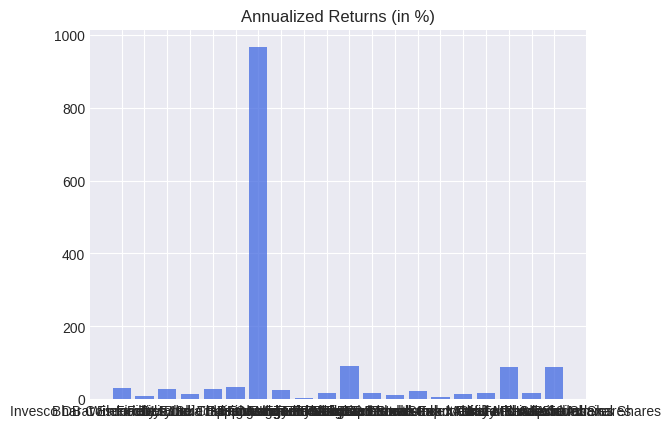

In [111]:
# Visualize the data
fig = plt.figure()
ax =plt.axes()

ax.bar(annual_returns.index, annual_returns*100, color='royalblue', alpha=0.75)
ax.set_title('Annualized Returns (in %)');

In [112]:
cumulative_return = (1 + returns).cumprod() - 1
cumulative_return.iloc[-1]

,2025-07-30
Ticker,
Bharat Electronics Ltd.,10.171635
Invesco DB Commodity Index Tracing Fund,1.271391
DLF Ltd.,6.617137
WisdomTree India Earnings ETF,2.182923
Fidelity Blue Chip Growth Fund,10.386312
Fidelity Select Technology Portfolio,21.013562
HDFC Gold ETF,2.622972
Hindustan Zinc Ltd.,5.899118
Nippon India ETF Liquid Bees,0.459066


In [113]:
cumulative_return_bm = (1 + returns_bm).cumprod() - 1
cumulative_return_bm.iloc[-1]

,2025-07-30
Ticker,
LIQUIDBEES.NS,0.459066
NIFTYBEES.NS,2.233451


In [114]:
vols = returns.std()
vols

,0
Ticker,
Bharat Electronics Ltd.,0.022309
Invesco DB Commodity Index Tracing Fund,0.011707
DLF Ltd.,0.026605
WisdomTree India Earnings ETF,0.013927
Fidelity Blue Chip Growth Fund,0.015560
Fidelity Select Technology Portfolio,0.017453
HDFC Gold ETF,1.945030
Hindustan Zinc Ltd.,0.021426
Nippon India ETF Liquid Bees,0.000693


In [115]:
vols_bm = returns_bm.std()
vols_bm

,0
Ticker,
LIQUIDBEES.NS,0.000709
NIFTYBEES.NS,0.181714


In [116]:
# Calculate annualized volatilities
annual_vols = vols*sqrt(252)
annual_vols

,0
Ticker,
Bharat Electronics Ltd.,0.354137
Invesco DB Commodity Index Tracing Fund,0.185840
DLF Ltd.,0.422342
WisdomTree India Earnings ETF,0.221077
Fidelity Blue Chip Growth Fund,0.247007
Fidelity Select Technology Portfolio,0.277055
HDFC Gold ETF,30.876389
Hindustan Zinc Ltd.,0.340121
Nippon India ETF Liquid Bees,0.010999


In [117]:
annual_vols_bm = vols_bm*sqrt(252)
annual_vols_bm

,0
Ticker,
LIQUIDBEES.NS,0.011260
NIFTYBEES.NS,2.884626


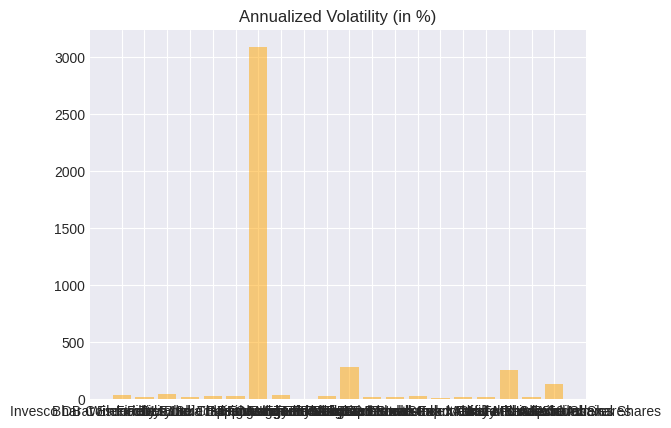

In [118]:
# Visualize the data
fig = plt.figure()
ax = plt.axes()

ax.bar(annual_vols.index, annual_vols*100, color='orange', alpha=0.5)
ax.set_title('Annualized Volatility (in %)');

In [119]:
cov_matrix = returns.cov()*252
cov_matrix

Ticker,Bharat Electronics Ltd.,Invesco DB Commodity Index Tracing Fund,DLF Ltd.,WisdomTree India Earnings ETF,Fidelity Blue Chip Growth Fund,Fidelity Select Technology Portfolio,HDFC Gold ETF,Hindustan Zinc Ltd.,Nippon India ETF Liquid Bees,Larsen & Toubro Ltd.,Niftybees Benchmark,S&P 500 Benchmark,Vanguard Real Estate Index Fund Admiral Shares,Vanguard Mid-Cap Growth Index Fund Admiral Shares,Vanguard Short-Term Investment-Grade Fund Admiral Shares,Vanguard Small-Cap Index Fund Admiral Shares,Vanguard Total Stock Market Index Fund Admiral Shares,Nifty IT Index,Nifty Mid Cap 50 Index,VIX Index
Ticker,,,,,,,,,,,,,,,,,,,,
Bharat Electronics Ltd.,0.125413,0.004220,0.063439,0.030193,0.007525,0.006836,-0.006948,0.038079,0.000185,0.040018,0.024554,0.007529,0.006099,0.004710,-0.001751,0.008046,0.007598,0.009918,0.043757,-0.064581
Invesco DB Commodity Index Tracing Fund,0.004220,0.034537,0.006290,0.013869,0.016458,0.016969,-0.026769,0.002880,-0.000065,0.003530,-0.000233,0.015181,0.012681,0.015083,0.002613,0.018016,0.015634,0.006701,0.003592,-0.067616
DLF Ltd.,0.063439,0.006290,0.178372,0.042241,0.013006,0.012242,-0.152139,0.049275,0.000157,0.052718,0.024586,0.011871,0.012440,0.009549,-0.002335,0.014317,0.012299,0.009811,0.060785,-0.102812
WisdomTree India Earnings ETF,0.030193,0.013869,0.042241,0.048875,0.032145,0.033690,-0.057369,0.018647,0.000052,0.023697,0.013512,0.028232,0.026860,0.029960,0.003086,0.031691,0.029020,0.003382,0.027490,-0.139793
Fidelity Blue Chip Growth Fund,0.007525,0.016458,0.013006,0.032145,0.061012,0.062735,-0.018903,0.003553,-0.000016,0.007847,0.004465,0.043086,0.033018,0.051243,0.002653,0.046249,0.044332,0.003340,0.008667,-0.218762
Fidelity Select Technology Portfolio,0.006836,0.016969,0.012242,0.033690,0.062735,0.076760,-0.015841,0.003515,-0.000013,0.007806,0.004862,0.045657,0.034445,0.055540,0.002663,0.048188,0.046851,0.002144,0.008558,-0.232251
HDFC Gold ETF,-0.006948,-0.026769,-0.152139,-0.057369,-0.018903,-0.015841,953.351410,0.136850,-0.001291,-0.009427,86.439441,-0.019069,-0.087210,-0.040258,-0.032423,-0.030191,-0.026503,-0.023900,-0.034189,0.026417
Hindustan Zinc Ltd.,0.038079,0.002880,0.049275,0.018647,0.003553,0.003515,0.136850,0.115683,0.000108,0.026820,0.031741,0.002912,0.001317,0.002166,-0.001964,0.003000,0.002831,0.009407,0.032840,-0.038616
Nippon India ETF Liquid Bees,0.000185,-0.000065,0.000157,0.000052,-0.000016,-0.000013,-0.001291,0.000108,0.000121,0.000081,-0.000048,-0.000031,-0.000011,-0.000028,-0.000008,-0.000040,-0.000026,-0.000059,0.000149,0.000050


In [120]:
corr_matrix = returns.corr()
corr_matrix

Ticker,Bharat Electronics Ltd.,Invesco DB Commodity Index Tracing Fund,DLF Ltd.,WisdomTree India Earnings ETF,Fidelity Blue Chip Growth Fund,Fidelity Select Technology Portfolio,HDFC Gold ETF,Hindustan Zinc Ltd.,Nippon India ETF Liquid Bees,Larsen & Toubro Ltd.,Niftybees Benchmark,S&P 500 Benchmark,Vanguard Real Estate Index Fund Admiral Shares,Vanguard Mid-Cap Growth Index Fund Admiral Shares,Vanguard Short-Term Investment-Grade Fund Admiral Shares,Vanguard Small-Cap Index Fund Admiral Shares,Vanguard Total Stock Market Index Fund Admiral Shares,Nifty IT Index,Nifty Mid Cap 50 Index,VIX Index
Ticker,,,,,,,,,,,,,,,,,,,,
Bharat Electronics Ltd.,1.000000,0.064125,0.424149,0.385646,0.086027,0.069677,-0.000635,0.316141,0.047444,0.429849,0.024633,0.111045,0.079060,0.046088,-0.068182,0.101589,0.109585,0.010912,0.591092,-0.133444
Invesco DB Commodity Index Tracing Fund,0.064125,1.000000,0.080133,0.337576,0.358538,0.329573,-0.004665,0.045558,-0.031557,0.072261,-0.000446,0.426680,0.313245,0.281223,0.193938,0.433485,0.429717,0.014049,0.092456,-0.266242
DLF Ltd.,0.424149,0.080133,1.000000,0.452404,0.124668,0.104622,-0.011667,0.343028,0.033843,0.474815,0.020682,0.146816,0.135210,0.078345,-0.076265,0.151581,0.148754,0.009051,0.688505,-0.178133
WisdomTree India Earnings ETF,0.385646,0.337576,0.452404,1.000000,0.588652,0.550029,-0.008404,0.247990,0.021585,0.407739,0.021714,0.667041,0.557725,0.469583,0.192502,0.640986,0.670492,0.005961,0.594844,-0.462706
Fidelity Blue Chip Growth Fund,0.086027,0.358538,0.124668,0.588652,1.000000,0.916715,-0.002479,0.042291,-0.005809,0.120841,0.006422,0.911129,0.613628,0.718853,0.148162,0.837248,0.916765,0.005268,0.167859,-0.648076
Fidelity Select Technology Portfolio,0.069677,0.329573,0.104622,0.550029,0.916715,1.000000,-0.001852,0.037302,-0.004199,0.107169,0.006235,0.860790,0.570722,0.694636,0.132544,0.777743,0.863781,0.003016,0.147769,-0.613415
HDFC Gold ETF,-0.000635,-0.004665,-0.011667,-0.008404,-0.002479,-0.001852,1.000000,0.013031,-0.003800,-0.001161,0.994592,-0.003226,-0.012966,-0.004518,-0.014483,-0.004372,-0.004385,-0.000302,-0.005297,0.000626
Hindustan Zinc Ltd.,0.316141,0.045558,0.343028,0.247990,0.042291,0.037302,0.013031,1.000000,0.028911,0.299952,0.033155,0.044725,0.017778,0.022070,-0.079637,0.039438,0.042509,0.010776,0.461899,-0.083080
Nippon India ETF Liquid Bees,0.047444,-0.031557,0.033843,0.021585,-0.005809,-0.004199,-0.003800,0.028911,1.000000,0.028026,-0.001535,-0.014543,-0.004393,-0.008885,-0.010151,-0.016303,-0.012192,-0.002107,0.064864,0.003301


In [121]:
from sklearn.covariance import LedoitWolf

def get_shrunk_covariance(returns):
    lw_estimator = LedoitWolf(store_precision=False, assume_centered=False)
    lw_estimator.fit(returns)

    # Get the sample covariance
    sample_cov = returns.cov().values

    # Get the shrunk covariance
    shrunk_cov = lw_estimator.covariance_

    # Manually control shrinkage (blend between sample and shrunk)
    alpha = 0.3  # 30% shrinkage, 70% sample covariance
    blended_cov = alpha * shrunk_cov + (1 - alpha) * sample_cov

    # Annualize
    annualized_covariance = blended_cov * 252
    return annualized_covariance
column_headers = returns.columns
shrunk_returns = get_shrunk_covariance(returns)
shrunk_df = pd.DataFrame(shrunk_returns,
                          index=column_headers,
                          columns=column_headers)
shrunk_df

Ticker,Bharat Electronics Ltd.,Invesco DB Commodity Index Tracing Fund,DLF Ltd.,WisdomTree India Earnings ETF,Fidelity Blue Chip Growth Fund,Fidelity Select Technology Portfolio,HDFC Gold ETF,Hindustan Zinc Ltd.,Nippon India ETF Liquid Bees,Larsen & Toubro Ltd.,Niftybees Benchmark,S&P 500 Benchmark,Vanguard Real Estate Index Fund Admiral Shares,Vanguard Mid-Cap Growth Index Fund Admiral Shares,Vanguard Short-Term Investment-Grade Fund Admiral Shares,Vanguard Small-Cap Index Fund Admiral Shares,Vanguard Total Stock Market Index Fund Admiral Shares,Nifty IT Index,Nifty Mid Cap 50 Index,VIX Index
Ticker,,,,,,,,,,,,,,,,,,,,
Bharat Electronics Ltd.,14.643318,0.002954,0.044407,0.021135,0.005268,0.004785,-0.004864,0.026655,0.000129,0.028013,0.017188,0.005270,0.004269,0.003297,-0.001225,0.005632,0.005318,0.006942,0.030630,-0.045207
Invesco DB Commodity Index Tracing Fund,0.002954,14.579705,0.004403,0.009709,0.011521,0.011878,-0.018739,0.002016,-0.000045,0.002471,-0.000163,0.010626,0.008877,0.010558,0.001829,0.012611,0.010944,0.004691,0.002514,-0.047332
DLF Ltd.,0.044407,0.004403,14.680390,0.029569,0.009104,0.008569,-0.106498,0.034493,0.000110,0.036903,0.017210,0.008310,0.008708,0.006684,-0.001635,0.010022,0.008610,0.006868,0.042549,-0.071968
WisdomTree India Earnings ETF,0.021135,0.009709,0.029569,14.589742,0.022501,0.023583,-0.040159,0.013053,0.000037,0.016588,0.009458,0.019763,0.018802,0.020972,0.002160,0.022184,0.020314,0.002367,0.019243,-0.097855
Fidelity Blue Chip Growth Fund,0.005268,0.011521,0.009104,0.022501,14.598238,0.043914,-0.013232,0.002487,-0.000011,0.005493,0.003125,0.030160,0.023113,0.035870,0.001857,0.032374,0.031033,0.002338,0.006067,-0.153133
Fidelity Select Technology Portfolio,0.004785,0.011878,0.008569,0.023583,0.043914,14.609261,-0.011089,0.002461,-0.000009,0.005464,0.003404,0.031960,0.024112,0.038878,0.001864,0.033732,0.032796,0.001501,0.005991,-0.162575
HDFC Gold ETF,-0.004864,-0.018739,-0.106498,-0.040159,-0.013232,-0.011089,681.901516,0.095795,-0.000903,-0.006599,60.507609,-0.013349,-0.061047,-0.028181,-0.022696,-0.021134,-0.018552,-0.016730,-0.023932,0.018492
Hindustan Zinc Ltd.,0.026655,0.002016,0.034493,0.013053,0.002487,0.002461,0.095795,14.636507,0.000076,0.018774,0.022219,0.002039,0.000922,0.001516,-0.001375,0.002100,0.001981,0.006585,0.022988,-0.027031
Nippon India ETF Liquid Bees,0.000129,-0.000045,0.000110,0.000037,-0.000011,-0.000009,-0.000903,0.000076,14.555614,0.000057,-0.000033,-0.000021,-0.000007,-0.000020,-0.000006,-0.000028,-0.000018,-0.000042,0.000104,0.000035


In [122]:
manual_aum = {
    'GOLDBEES.NS': 3.2605e+11,
    'LIQUIDBEES.NS': 1.1474e+11,
    'NIFTYBEES.NS' : 5.3989e+11,
    '^CNXIT' : 2.897e+10,
    '^NSEMDCP50' : 2.3e+11,
    '^VIX' : 2.737e+10,

    }

num = np.arange(len(asset_symbols))
market_cap = np.zeros(len(asset_symbols))

for i in num:
    symbol = asset_symbols[i]
    if symbol in manual_aum:
        market_cap[i] = manual_aum[symbol]
        print(f"Using manual AUM for {symbol}")
        continue
    ticker = InrTicker(symbol)

    assets = ticker.info.get('totalAssets', None)
    m_cap = ticker.info.get('marketCap', None)

    if assets is not None:
        market_cap[i] = assets
    elif m_cap is not None:
        market_cap[i] = m_cap
    else:
        market_cap[i] = 0
        print(f"Warning: Could not find data for {symbol}")

print("\nFinal Data Array:")
print(market_cap)

Using manual AUM for LIQUIDBEES.NS
Using manual AUM for ^CNXIT
Using manual AUM for GOLDBEES.NS
Using manual AUM for ^NSEMDCP50
Using manual AUM for ^VIX
Using manual AUM for NIFTYBEES.NS

Final Data Array:
[1.14740000e+11 1.75301237e+12 5.48581671e+12 2.89700000e+10
 2.13125077e+12 3.26050000e+11 2.95278530e+12 2.30000000e+11
 1.17128405e+11 2.51294197e+11 1.76264154e+12 7.61948059e+12
 2.81338450e+11 1.46370683e+13 3.75682105e+12 1.81816873e+14
 2.73700000e+10 5.92133978e+12 6.06483253e+13 5.39890000e+11]


In [123]:
# 1. Calculate market-cap weights
market_weights = market_cap / market_cap.sum()

# 2. Calculate the market's risk aversion (delta)
# A common method is to use the market's Sharpe Ratio.
market_returns_annual = (1 + returns.mean()).prod()**252 - 1
market_vol_annual = returns.std() * np.sqrt(252)
# Assuming a simple equal-weighted market portfolio for Sharpe calculation
sharpe_ratio_market = np.mean(market_returns_annual) / np.mean(market_vol_annual)
risk_aversion = sharpe_ratio_market / np.mean(market_vol_annual) # delta

# 3. Calculate the final implied returns vector (Pi)
implied_returns = risk_aversion * shrunk_df.dot(market_weights)

print("--- Annual Market-Implied Returns (Π) ---")
print((implied_returns * 100).round(2).to_string())

--- Annual Market-Implied Returns (Π) ---
Ticker
Bharat Electronics Ltd.                                     1.384258e+06
Invesco DB Commodity Index Tracing Fund                     7.892068e+06
DLF Ltd.                                                    2.370848e+07
WisdomTree India Earnings ETF                               1.731605e+06
Fidelity Blue Chip Growth Fund                              1.064977e+07
Fidelity Select Technology Portfolio                        3.393172e+06
HDFC Gold ETF                                               5.904505e+08
Hindustan Zinc Ltd.                                         1.600405e+06
Nippon India ETF Liquid Bees                                4.758228e+05
Larsen & Toubro Ltd.                                        1.837900e+06
Niftybees Benchmark                                         6.026639e+07
S&P 500 Benchmark                                           3.266077e+07
Vanguard Real Estate Index Fund Admiral Shares              2.745655e+06
Va

In [124]:
from cvxpy.reductions.solvers.conic_solvers.qoco_conif import QOCO

q = np.array([
    0.06,  # View 1: Nifty 50  > LiquidBees
    0.02,  # View 2: Nifty 50  > S&P 500
    0.03,  # View 3: FSPTX     > Nifty IT
    0.04   # View 4: Gold ETF  > LiquidBees
])[:, np.newaxis]

p = np.zeros((4, 20))

# View 1
p[0, 10] = 1.0   # Niftybees Benchmark
p[0, 8]  = -1.0  # Nippon India ETF Liquid Bees

# View 2
p[1, 10] = 1.0   # Niftybees Benchmark
p[1, 11] = -1.0  # S&P 500 Benchmark

# View 3
p[2, 6] = 1.0   # US IT Index
p[2, 17] = -1.0  # Nifty IT Index

# View 4
p[3, 6]  = 1.0   # HDFC Gold ETF
p[3, 8]  = -1.0  # Nippon India ETF Liquid Bees


tau = 0.02
omega_base = np.diag(np.diag(p @ shrunk_df @ p.T))

conf_percent = np.array([
    0.90,  #Nifty > LiquidBees
    0.80,  #Nifty > SPY
    0.75,
    0.65,
])

strength = conf_percent / conf_percent.mean()
omega_diag = np.diag(omega_base) / strength
omega = np.diag(omega_diag)

In [125]:
# The Black-Litterman formula for the posterior expected returns
bl_part_1 = np.linalg.inv(np.linalg.inv(tau * shrunk_df) + p.T @ np.linalg.inv(omega) @ p)
bl_part_2 = np.linalg.inv(tau * shrunk_df) @ implied_returns + p.T @ np.linalg.inv(omega) @ q.flatten()
black_litterman_returns = bl_part_1 @ bl_part_2

# Present the final returns nicely
bl_returns_df = pd.DataFrame({'Implied': implied_returns, 'Black-Litterman': black_litterman_returns},
                             returns.columns)

print("\n--- Final Blended Expected Returns (in %) ---")
print(bl_returns_df.mul(100).round(2))


--- Final Blended Expected Returns (in %) ---
                                                         Implied  \
Ticker                                                             
Bharat Electronics Ltd.                             1.384258e+06   
Invesco DB Commodity Index Tracing Fund             7.892068e+06   
DLF Ltd.                                            2.370848e+07   
WisdomTree India Earnings ETF                       1.731605e+06   
Fidelity Blue Chip Growth Fund                      1.064977e+07   
Fidelity Select Technology Portfolio                3.393172e+06   
HDFC Gold ETF                                       5.904505e+08   
Hindustan Zinc Ltd.                                 1.600405e+06   
Nippon India ETF Liquid Bees                        4.758228e+05   
Larsen & Toubro Ltd.                                1.837900e+06   
Niftybees Benchmark                                 6.026639e+07   
S&P 500 Benchmark                                   3.266077e+07   
V

In [132]:
import pandas as pd
import cvxpy as cp

# Add 'asset_names' as a new argument
def optimize_portfolio(returns_np, shrunk_df, risk_aversion, asset_names):

    num_assets = len(returns_np)
    weights = cp.Variable(num_assets)

    expected_return = weights @ returns_np
    risk = cp.quad_form(weights, shrunk_df)

    objective = cp.Maximize(expected_return - 0.5 * risk_aversion * risk)
    constraints = [cp.sum(weights) == 1,
                   weights >= 0,
                   weights <= 0.20,
                   risk <= 1.44]


    problem = cp.Problem(objective, constraints)
    problem.solve()

    if problem.status == 'optimal':
        # Use the 'asset_names' list you passed in
        return pd.Series(weights.value, index=asset_names)
    else:
        return None

    # Get the asset names from your original returns DataFrame/Series
asset_names = returns.columns

# Call the updated function with the asset names as the last argument
optimal_weights = optimize_portfolio(
    black_litterman_returns,
    shrunk_df,
    risk_aversion,
    asset_names # <-- Pass the labels here
)

print(optimal_weights)

Ticker
Bharat Electronics Ltd.                                     0.030683
Invesco DB Commodity Index Tracing Fund                     0.035085
DLF Ltd.                                                    0.043473
WisdomTree India Earnings ETF                               0.030856
Fidelity Blue Chip Growth Fund                              0.036185
Fidelity Select Technology Portfolio                        0.031857
HDFC Gold ETF                                               0.005051
Hindustan Zinc Ltd.                                         0.030996
Nippon India ETF Liquid Bees                                0.031556
Larsen & Toubro Ltd.                                        0.031131
Niftybees Benchmark                                         0.031393
S&P 500 Benchmark                                           0.049437
Vanguard Real Estate Index Fund Admiral Shares              0.031679
Vanguard Mid-Cap Growth Index Fund Admiral Shares           0.066164
Vanguard Short-Term Investm

In [133]:
optimal_weights.sum()

np.float64(1.0000000000000002)

In [134]:
optimal_weights[np.abs(optimal_weights) < 1e-7] = 0
cleaned_weights = optimal_weights / optimal_weights.sum()
print("--- Cleaned Portfolio Weights ---")
print(cleaned_weights.round(4))

--- Cleaned Portfolio Weights ---
Ticker
Bharat Electronics Ltd.                                     0.0307
Invesco DB Commodity Index Tracing Fund                     0.0351
DLF Ltd.                                                    0.0435
WisdomTree India Earnings ETF                               0.0309
Fidelity Blue Chip Growth Fund                              0.0362
Fidelity Select Technology Portfolio                        0.0319
HDFC Gold ETF                                               0.0051
Hindustan Zinc Ltd.                                         0.0310
Nippon India ETF Liquid Bees                                0.0316
Larsen & Toubro Ltd.                                        0.0311
Niftybees Benchmark                                         0.0314
S&P 500 Benchmark                                           0.0494
Vanguard Real Estate Index Fund Admiral Shares              0.0317
Vanguard Mid-Cap Growth Index Fund Admiral Shares           0.0662
Vanguard Short-Term I

--- My Portfolio Performance ---
Total Return: 1375.94%
Annualized Return (CAGR): 29.93%
Annualized Volatility (Risk): 28.79%
Sharpe Ratio: 1.04

--- S&P 500 Benchmark Performance ---
Total Return: 386.60%
Annualized Return (CAGR): 16.64%
Annualized Volatility (Risk): 19.14%
Sharpe Ratio: 0.87


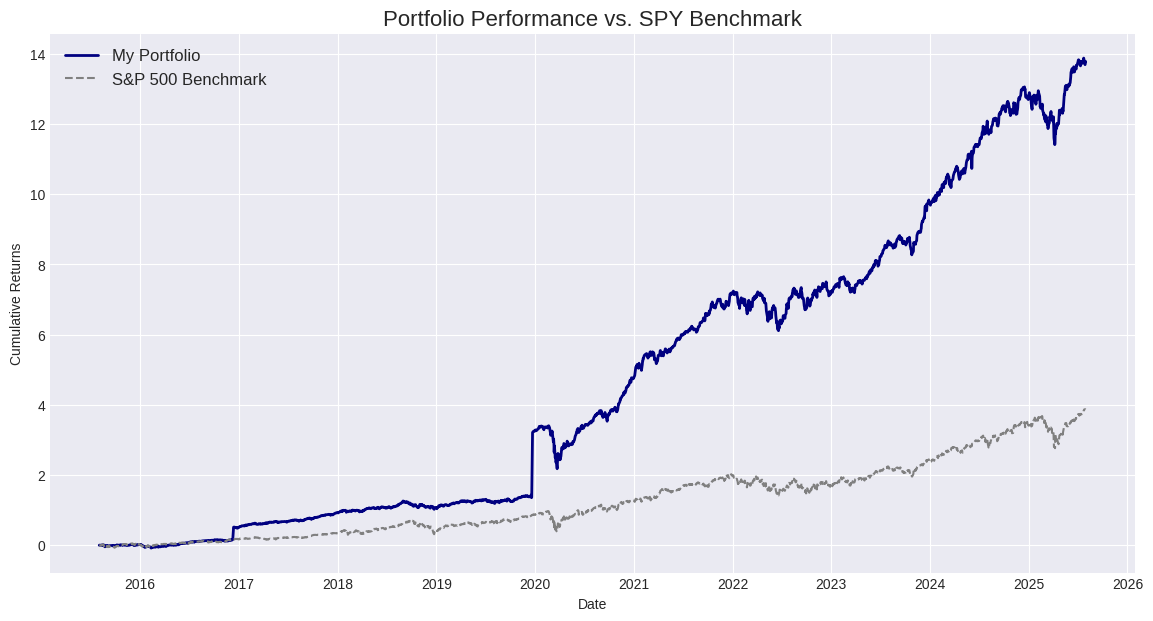

In [135]:
asset_returns = returns[asset_names]
benchmark_returns = returns['S&P 500 Benchmark']
portfolio_returns = asset_returns.dot(cleaned_weights)

# --- 3. PERFORMANCE METRIC CALCULATION ---

# Calculate cumulative returns for visualization
portfolio_cumulative_returns = (1 + portfolio_returns).cumprod() - 1
benchmark_cumulative_returns = (1 + benchmark_returns).cumprod() - 1

def calculate_performance_metrics(returns):
    """Calculates key performance metrics for a returns series."""
    total_return = (1 + returns).prod() - 1
    # Corrected annualized return (CAGR) calculation using geometric mean
    num_trading_days = len(returns)
    num_years = num_trading_days / 252.0  # Assuming 252 trading days in a year
    annualized_return = (1 + total_return)**(1 / num_years) - 1
    annualized_volatility = returns.std() * np.sqrt(252)
    sharpe_ratio = (annualized_return - average_rf) / annualized_volatility
    return {
        "Total Return": f"{total_return:.2%}",
        "Annualized Return (CAGR)": f"{annualized_return:.2%}",
        "Annualized Volatility (Risk)": f"{annualized_volatility:.2%}",
        "Sharpe Ratio": f"{sharpe_ratio:.2f}"
    }

portfolio_metrics = calculate_performance_metrics(portfolio_returns)
benchmark_metrics = calculate_performance_metrics(benchmark_returns)

print("--- My Portfolio Performance ---")
for key, value in portfolio_metrics.items():
    print(f"{key}: {value}")

print("\n--- S&P 500 Benchmark Performance ---")
for key, value in benchmark_metrics.items():
    print(f"{key}: {value}")


# --- 4. VISUALIZATION ---

plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(14, 7))

plt.plot(portfolio_cumulative_returns.index, portfolio_cumulative_returns, label='My Portfolio', color='navy', linewidth=2)
plt.plot(benchmark_cumulative_returns.index, benchmark_cumulative_returns, label='S&P 500 Benchmark', color='gray', linestyle='--')

plt.title('Portfolio Performance vs. SPY Benchmark', fontsize=16)
plt.ylabel('Cumulative Returns')
plt.xlabel('Date')
plt.legend(loc='upper left', fontsize=12)
plt.grid(True)
plt.show()

In [ ]:
assets_string = ' '.join(asset_symbols)
data4 = yf_inr_download(assets_string, start="2025-08-01", end="2025-11-30", auto_adjust=False)["Adj Close"]
data4 = data4.dropna()
data4

In [ ]:
# Create a reverse mapping from ticker symbol to asset name
asset_id_to_name_map = {v: k for k, v in asset_name_to_id_map.items()}

# Apply robust cleaning steps to data4
# Drop any columns from data4 that consist entirely of NaN values.
data4 = data4.dropna(axis=1, how='all')

# Apply forward-fill (ffill()) to handle any remaining NaN values.
data4 = data4.ffill()

# Apply backward-fill (bfill()) to handle any remaining NaN values.
data4 = data4.bfill()

# Drop any rows from data4 that still contain NaN values after filling.
data4 = data4.dropna(axis=0, how='any')

# Rename columns from ticker symbols to full asset names for data4
data4 = data4.rename(columns=asset_id_to_name_map)

# Calculate daily returns for the month
daily_returns_aug = data4.pct_change().dropna()

# Separate asset and benchmark returns
# Filter asset_names to only include columns available in daily_returns_aug
available_portfolio_assets = daily_returns_aug.columns.intersection(asset_names)
asset_returns_aug = daily_returns_aug[available_portfolio_assets]

# Check if benchmark is available before selecting
benchmark_name = 'Niftybees Benchmark'
if benchmark_name in daily_returns_aug.columns:
    benchmark_returns_aug = daily_returns_aug[benchmark_name]
else:
    print(f"Warning: '{benchmark_name}' not found in August data after cleaning. Skipping benchmark comparison for August.")
    benchmark_returns_aug = pd.Series(0, index=daily_returns_aug.index) # Create a dummy series to avoid error

# Calculate your portfolio's daily returns for August
# Align cleaned_weights with the available_portfolio_assets
aligned_weights = cleaned_weights.reindex(available_portfolio_assets).fillna(0)
# Re-normalize weights if some assets were removed (only if sum > 0 to avoid ZeroDivisionError)
aligned_weights = aligned_weights / aligned_weights.sum() if aligned_weights.sum() > 0 else aligned_weights
portfolio_returns_aug = asset_returns_aug.dot(aligned_weights)


# --- 4. MONTHLY PERFORMANCE METRIC CALCULATION ---

def calculate_monthly_metrics(returns):
    """Calculates key performance metrics for a single month/period."""
    # Calculate total return for the period
    period_total_return = (1 + returns).prod() - 1
    # Calculate volatility (standard deviation of daily returns)
    daily_volatility = returns.std()

    # Calculate Annualized Return (CAGR) and Annualized Volatility for Sharpe
    num_trading_days = len(returns)
    num_years = num_trading_days / 252.0  # Assuming 252 trading days in a year

    if num_years == 0: # Avoid division by zero if returns is empty
        annualized_return = 0
    else:
        annualized_return = (1 + period_total_return)**(1 / num_years) - 1

    annualized_volatility = daily_volatility * np.sqrt(252) # Annualized from daily std

    # Ensure annualized_volatility is not zero to avoid division by zero in Sharpe Ratio
    if annualized_volatility == 0:
        sharpe_ratio = 0
    else:
        sharpe_ratio = (annualized_return - average_rf) / annualized_volatility

    return {
        "Total Period Return": f"{period_total_return:.2%}",
        "Annualized Return (CAGR)": f"{annualized_return:.2%}",
        "Annualized Volatility (Risk)": f"{annualized_volatility:.2%}",
        "Sharpe Ratio": f"{sharpe_ratio:.2f}"
    }

portfolio_metrics = calculate_monthly_metrics(portfolio_returns_aug)
benchmark_metrics = calculate_monthly_metrics(benchmark_returns_aug)

print("--- My Portfolio Performance (August-November 2025) ---")
for key, value in portfolio_metrics.items():
    print(f"{key}: {value}")

print(f"\n--- {benchmark_name} Performance (August-November 2025) ---")
for key, value in benchmark_metrics.items():
    print(f"{key}: {value}")


# --- 5. VISUALIZATION (for August 2025) ---

# Calculate cumulative returns over the month
portfolio_cumulative_returns = (1 + portfolio_returns_aug).cumprod()
benchmark_cumulative_returns = (1 + benchmark_returns_aug).cumprod()

plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(14, 7))

# Plot starting from 1 to show growth over the month
plt.plot(portfolio_cumulative_returns.index, portfolio_cumulative_returns, label='My Portfolio', color='navy', linewidth=2)
plt.plot(benchmark_cumulative_returns.index, benchmark_cumulative_returns, label=benchmark_name, color='gray', linestyle='--')

plt.title('Performance in August-November 2025', fontsize=16)
plt.ylabel('Growth of 1 rupee')
plt.xlabel('Date')
plt.legend(loc='best', fontsize=12)
plt.grid(True)
plt.show()

In [ ]:
asset_returns = returns[asset_names]
benchmark_returns = returns['Niftybees Benchmark']
portfolio_returns = asset_returns.dot(cleaned_weights)

# --- 3. PERFORMANCE METRIC CALCULATION ---

# Calculate cumulative returns for visualization
portfolio_cumulative_returns = (1 + portfolio_returns).cumprod() - 1
benchmark_cumulative_returns = (1 + benchmark_returns).cumprod() - 1

def calculate_performance_metrics(returns):
    """Calculates key performance metrics for a returns series."""
    total_return = (1 + returns).prod() - 1
    # Corrected annualized return (CAGR) calculation using geometric mean
    num_trading_days = len(returns)
    num_years = num_trading_days / 252.0  # Assuming 252 trading days in a year
    annualized_return = (1 + total_return)**(1 / num_years) - 1
    annualized_volatility = returns.std() * np.sqrt(252)
    sharpe_ratio = (annualized_return - average_rf) / annualized_volatility
    return {
        "Total Return": f"{total_return:.2%}",
        "Annualized Return (CAGR)": f"{annualized_return:.2%}",
        "Annualized Volatility (Risk)": f"{annualized_volatility:.2%}",
        "Sharpe Ratio": f"{sharpe_ratio:.2f}"
    }

portfolio_metrics = calculate_performance_metrics(portfolio_returns)
benchmark_metrics = calculate_performance_metrics(benchmark_returns)

print("--- My Portfolio Performance ---")
for key, value in portfolio_metrics.items():
    print(f"{key}: {value}")

print("\n--- Niftybees Benchmark Performance ---")
for key, value in benchmark_metrics.items():
    print(f"{key}: {value}")


# --- 4. VISUALIZATION ---

plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(14, 7))

plt.plot(portfolio_cumulative_returns.index, portfolio_cumulative_returns, label='My Portfolio', color='navy', linewidth=2)
plt.plot(benchmark_cumulative_returns.index, benchmark_cumulative_returns, label='S&P 500 Benchmark', color='gray', linestyle='--')

plt.title('Portfolio Performance vs. Nifty 50 Benchmark', fontsize=16)
plt.ylabel('Cumulative Returns')
plt.xlabel('Date')
plt.legend(loc='upper left', fontsize=12)
plt.grid(True)
plt.show()